# Fresh Retail: Starter Notebook

This notebook accompanies the **Introduction** slide deck (`FreshRetail_Introduction.pptx`). It provides a shared data pipeline for both tracks, then produces the exact outputs previewed in the showcase slides.

**Run sections 1–4 first** (shared setup), then run the section for your track:

| Section | Track | What you produce |
|---------|-------|-----------------|
| 5. Operations | Ops | Temporal profiles, heatmaps, KPIs, hourly patterns |
| 6. Data Science | DS | WAPE baselines, forecast overlays, demand recovery, error analysis |

Both tracks use the same dataset, same helper functions, and same time split.

- **Operations Track**: O1 (Diagnosis) or O2 (Decision)
- **Data Science Track**: D1 (Direct benchmark) or D2 (Recovery first)

**Dataset**: [Dingdong-Inc/FreshRetailNet-50K](https://huggingface.co/datasets/Dingdong-Inc/FreshRetailNet-50K)

---
## 1. Setup and Data Download

In [31]:
# Run this cell on Google Colab (already installed locally)
%pip install -q pandas pyarrow matplotlib seaborn datasets

Note: you may need to restart the kernel to use updated packages.


In [32]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
import importlib


sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

print("Setup complete.")

Setup complete.


In [33]:
from datasets import load_dataset

print("Downloading FreshRetailNet-50K from Hugging Face...")
ds = load_dataset("Dingdong-Inc/FreshRetailNet-50K")
print(ds)

# Convert to pandas
train_raw = ds["train"].to_pandas()
eval_raw = ds["eval"].to_pandas()

print(f"\nTrain: {train_raw.shape}, Eval: {eval_raw.shape}")
print(f"Columns: {list(train_raw.columns)}")

DatasetDict({
    train: Dataset({
        features: ['city_id', 'store_id', 'management_group_id', 'first_category_id', 'second_category_id', 'third_category_id', 'product_id', 'dt', 'sale_amount', 'hours_sale', 'stock_hour6_22_cnt', 'hours_stock_status', 'discount', 'holiday_flag', 'activity_flag', 'precpt', 'avg_temperature', 'avg_humidity', 'avg_wind_level'],
        num_rows: 4500000
    })
    eval: Dataset({
        features: ['city_id', 'store_id', 'management_group_id', 'first_category_id', 'second_category_id', 'third_category_id', 'product_id', 'dt', 'sale_amount', 'hours_sale', 'stock_hour6_22_cnt', 'hours_stock_status', 'discount', 'holiday_flag', 'activity_flag', 'precpt', 'avg_temperature', 'avg_humidity', 'avg_wind_level'],
        num_rows: 350000
    })
})

Train: (4500000, 19), Eval: (350000, 19)
Columns: ['city_id', 'store_id', 'management_group_id', 'first_category_id', 'second_category_id', 'third_category_id', 'product_id', 'dt', 'sale_amount', 'hours_sale', 'sto

---
## 2. Data Preparation

In [34]:
import utils

importlib.reload(utils)
history = utils.prepare_panel(train_raw)

# Apply shared pipeline
history = utils.flag_censoring(history)
history = utils.make_features(history)

pd.set_option('display.max_columns', None)   # show all columns
pd.set_option('display.width', None)         # avoid line wrapping
pd.set_option('display.max_colwidth', None)  # optional: full cell contents

history.head()

Prepared 4,500,000 rows — 50,000 series x 90 days
Date range: 2024-03-28 to 2024-06-25
Censored rows: 1,992,006 / 4,500,000 (44.3%)


,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,sale_amount,hours_sale,stock_hour6_22_cnt,hours_stock_status,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level,series_id,day_idx,is_censored,censoring_severity,sales_lag1,sales_lag7,sales_roll7,sales_roll28,psd
0,0,0,2,29,78,82,4,2024-03-28,0.5,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]",13,"[1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",0.882,0,1,1.6999,15.48,73.54,1.97,1,1,1,0.8125,NaN,NaN,0.500000,0.500000,2.701111
1,0,0,2,29,78,82,4,2024-03-29,1.3,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.3, 0.8, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]",5,"[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1]",0.882,0,1,3.0190,15.08,76.56,1.71,1,2,1,0.3125,0.5,NaN,0.900000,0.900000,2.701111
2,0,0,2,29,78,82,4,2024-03-30,5.3,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.7, 1.4, 0.3, 0.0, 0.0, 1.1, 0.2, 0.1, 1.3, 0.2, 0.0, 0.0, 0.0, 0.0, 0.0]",0,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0.882,1,1,2.0942,15.91,76.47,1.73,1,3,0,0.0000,1.3,NaN,2.366667,2.366667,2.701111
3,0,0,2,29,78,82,4,2024-03-31,4.2,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.5, 0.2, 0.0, 0.0, 0.3, 1.2, 0.3, 0.6, 0.0, 0.0, 0.1, 0.0, 0.0, 0.0]",0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0.879,1,1,1.5618,16.13,77.40,1.76,1,4,0,0.0000,5.3,NaN,2.825000,2.825000,2.701111
4,0,0,2,29,78,82,4,2024-04-01,0.7,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.0, 0.0, 0.0, 0.3, 0.0, 0.0, 0.0]",0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0.882,0,1,3.5386,15.37,78.26,1.25,1,5,0,0.0000,4.2,NaN,2.400000,2.400000,2.701111


---
## 4. Data at a Glance

In [35]:
# Show a real series with stockouts
series_stockouts = history.groupby("series_id")["is_censored"].mean()
example_sid = series_stockouts[(series_stockouts > 0.3) & (series_stockouts < 0.7)].index[0]

history["datum"] = pd.to_datetime(history["dt"])
history["weekday"] = history["datum"].dt.day_name()

s_example = history[history["series_id"] == example_sid][
    #["dt", "holiday_flag", "weekday"]
    ["dt", "day_idx", "sale_amount", "stock_hour6_22_cnt", "is_censored", "discount", "holiday_flag", "avg_temperature"]

].head(14)
print(f"Series {example_sid} \u2014 first 14 days (a product with frequent stockouts):")
display(s_example)

Series 1 — first 14 days (a product with frequent stockouts):


,dt,day_idx,sale_amount,stock_hour6_22_cnt,is_censored,discount,holiday_flag,avg_temperature
0,2024-03-28,1,0.5,13,1,0.882,0,15.48
1,2024-03-29,2,1.3,5,1,0.882,0,15.08
2,2024-03-30,3,5.3,0,0,0.882,1,15.91
3,2024-03-31,4,4.2,0,0,0.879,1,16.13
4,2024-04-01,5,0.7,0,0,0.882,0,15.37
5,2024-04-02,6,2.3,0,0,0.882,0,15.69
6,2024-04-03,7,1.3,5,1,0.877,0,16.11
7,2024-04-04,8,4.7,0,0,0.879,1,16.08
8,2024-04-05,9,3.1,1,1,0.876,1,16.24
9,2024-04-06,10,5.5,3,1,0.876,1,16.72


In [36]:
# Dataset dimensions
summary = pd.Series({
    "Total rows": f"{len(history):,}",
    "Series (store x product)": f"{history['series_id'].nunique():,}",
    "Days per series": str(history["day_idx"].nunique()),
    "Products (product_id)": str(history["product_id"].nunique()),
    "Stores (store_id)": str(history["store_id"].nunique()),
    "Cities (city_id)": str(history["city_id"].nunique()),
    "Management groups": str(history["management_group_id"].nunique()),
    "Mean daily sales": f"{history['sale_amount'].mean():.3f}",
    "Censored rows": f"{history['is_censored'].sum():,} ({history['is_censored'].mean():.1%})",
    "Low-sale series (psd<1)": f"{(history.groupby('series_id')['psd'].first() < 1).sum():,}",
    "High-sale series (psd>=1)": f"{(history.groupby('series_id')['psd'].first() >= 1).sum():,}",
})
display(summary.to_frame("Value"))

,Value
Total rows,"4,500,000"
Series (store x product),"50,000"
Days per series,90
Products (product_id),865
Stores (store_id),898
Cities (city_id),18
Management groups,7
Mean daily sales,0.999
Censored rows,"1,992,006 (44.3%)"
Low-sale series (psd<1),"36,448"


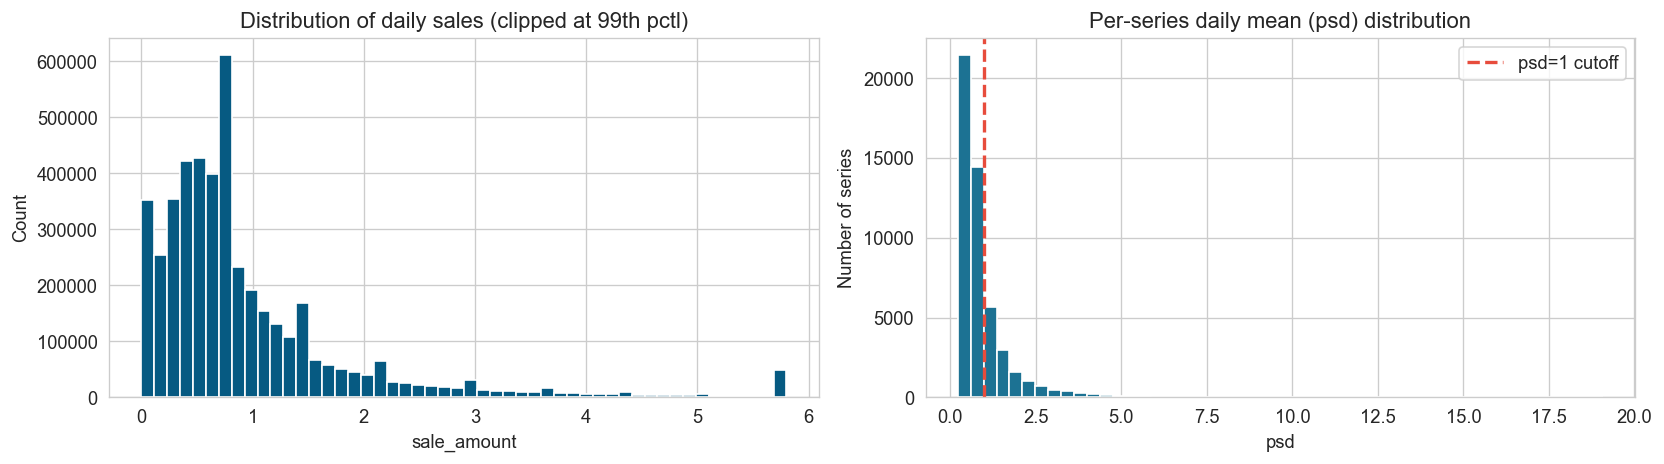

In [37]:
# Sales distribution and per-series daily mean
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

clipped = history["sale_amount"].clip(upper=history["sale_amount"].quantile(0.99))
axes[0].hist(clipped, bins=50, color="#065A82", edgecolor="white")
axes[0].set_title("Distribution of daily sales (clipped at 99th pctl)")
axes[0].set_xlabel("sale_amount")
axes[0].set_ylabel("Count")

psd_vals = history.groupby("series_id")["psd"].first()
axes[1].hist(psd_vals, bins=50, color="#1C7293", edgecolor="white")
axes[1].axvline(1.0, color="#E74C3C", linestyle="--", linewidth=2, label="psd=1 cutoff")
axes[1].set_title("Per-series daily mean (psd) distribution")
axes[1].set_xlabel("psd")
axes[1].set_ylabel("Number of series")
axes[1].legend()

plt.tight_layout()
plt.show()

---
---
# DATA SCIENCE TRACK

## 6. Data Science Track

> **You may skip this section if you are focusing on the Operations track.**

This section produces the following outputs — each corresponds to a slide in the deck:

| Output | What it shows | Slide |
|--------|--------------|-------|
| WAPE results table (D1) | Baseline comparison: global mean vs seasonal naive vs rolling 28d | Slide 18 |
| Forecast overlay chart | Predicted vs actual for one series across the validation window | Slide 18 |
| Recovery comparison table (D2) | WAPE on raw vs corrected target — does imputation help? | Slide 19 |
| WAPE by management group | Which product groups are hardest to forecast? | Slide 20 |
| Residual histogram + error scatter | Where the model fails and why | Slide 20 |

**A strong data science project** starts from these baselines and improves on them with better features, better imputation, or a more sophisticated model — always measured by WAPE on the same time split.

### 6a. WAPE Evaluation Function

in utils

### 6b. D1 \u2014 Direct Benchmark: Naive Baselines on Raw Sales

In [38]:
train, val = utils.time_split(history, horizon=7)
print(f"\nValidation window: day {val['day_idx'].min()} to {val['day_idx'].max()}")

# --- Baseline 1: Global mean ---
series_mean = train.groupby("series_id")["sale_amount"].mean().rename("pred_global_mean")
val = val.drop(columns=["pred_global_mean", "pred_seasonal_naive", "pred_roll28", "forecast_day"], errors="ignore")
val = val.merge(series_mean, on="series_id", how="left")

# --- Baseline 2: Seasonal naive (last-week repeat) ---
val_start = val["day_idx"].min()
last_week = history[history["day_idx"].between(val_start - 7, val_start - 1)][["series_id", "day_idx", "sale_amount"]].copy()
last_week["forecast_day"] = last_week["day_idx"] + 7
last_week = last_week.rename(columns={"sale_amount": "pred_seasonal_naive"})

val = val.merge(last_week[["series_id", "forecast_day", "pred_seasonal_naive"]],
                left_on=["series_id", "day_idx"], right_on=["series_id", "forecast_day"], how="left")
val = val.drop(columns=["forecast_day"], errors="ignore")
val["pred_seasonal_naive"] = val["pred_seasonal_naive"].fillna(val["pred_global_mean"])

# --- Baseline 3: Rolling 28-day mean ---
roll28 = train.groupby("series_id")["sale_amount"].apply(
    lambda x: x.tail(28).mean(), include_groups=False
).rename("pred_roll28")
val = val.merge(roll28, on="series_id", how="left")

# Evaluate all three
results = {}
for method, col in [("Global mean", "pred_global_mean"), ("Seasonal naive", "pred_seasonal_naive"), ("Rolling 28d", "pred_roll28")]:
    val["prediction"] = val[col].clip(lower=0)
    results[method] = utils.evaluate_forecast(val)

results_df = pd.DataFrame(results).T
print("=== D1 Benchmark Results ===")
display(results_df)

Train: day 1..83 (4,150,000 rows), Val: day 84..90 (350,000 rows)

Validation window: day 84 to 90
=== D1 Benchmark Results ===


,wape_overall,wape_low_sale,wape_high_sale,harmonic_mean,scored_rows
Global mean,0.4336,0.4508,0.4203,0.4345,198987.0
Seasonal naive,0.3976,0.4830,0.3317,0.3947,198987.0
Rolling 28d,0.3637,0.4143,0.3247,0.3639,198987.0


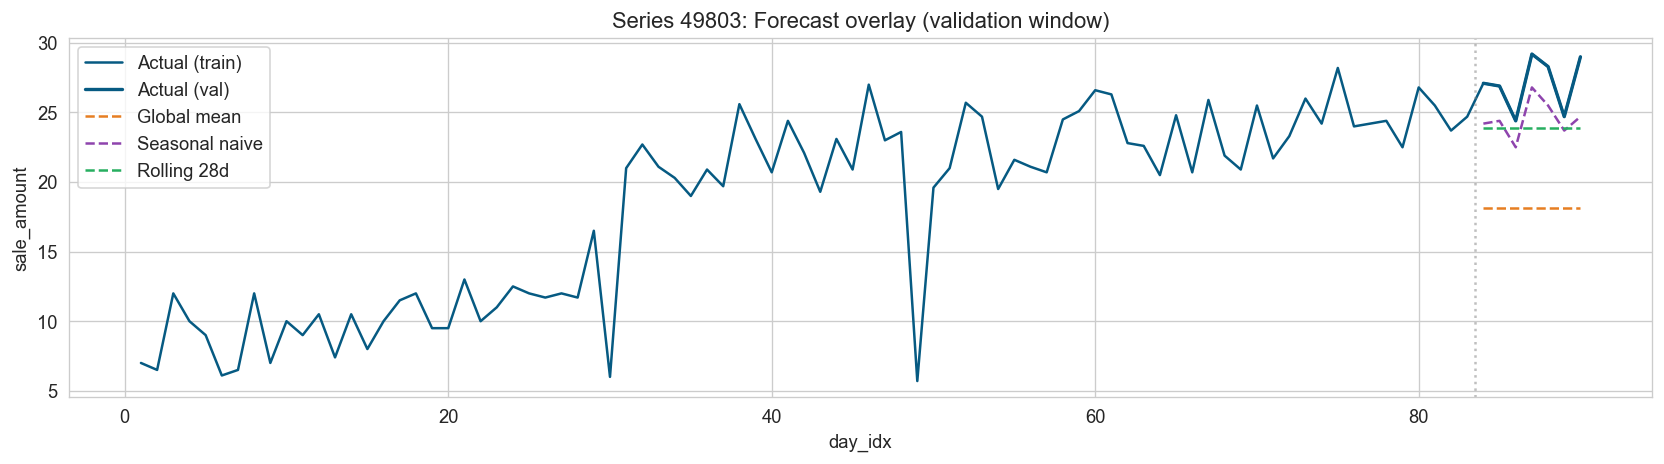

In [39]:
# --- Visualize: forecast overlay for one series ---
example_sid3 = history.groupby("series_id")["psd"].first().sort_values(ascending=False).index[5]
ex = history[history["series_id"] == example_sid3].copy()
ex_val = val[val["series_id"] == example_sid3].copy()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ex["day_idx"], ex["sale_amount"], color="#065A82", linewidth=1.5, label="Actual (train)")
ax.plot(ex_val["day_idx"], ex_val["sale_amount"], color="#065A82", linewidth=2, linestyle="-", label="Actual (val)")
ax.plot(ex_val["day_idx"], ex_val["pred_global_mean"], color="#E67E22", linewidth=1.5, linestyle="--", label="Global mean")
ax.plot(ex_val["day_idx"], ex_val["pred_seasonal_naive"], color="#8E44AD", linewidth=1.5, linestyle="--", label="Seasonal naive")
ax.plot(ex_val["day_idx"], ex_val["pred_roll28"], color="#27AE60", linewidth=1.5, linestyle="--", label="Rolling 28d")

ax.axvline(ex_val["day_idx"].min() - 0.5, color="gray", linestyle=":", alpha=0.5)
ax.set_title(f"Series {example_sid3}: Forecast overlay (validation window)")
ax.set_xlabel("day_idx")
ax.set_ylabel("sale_amount")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

### 6c. D2 \u2014 Recovery First: Impute Censored Hours, Then Forecast

In [40]:
# Expand hourly data from the list columns
# Note: this creates large arrays (~550MB). Colab free tier (12GB RAM) handles this fine.
print("Expanding hourly data...")

hourly_sales = np.stack(history["hours_sale"].values)          # (N, 24)
hourly_stock_ds = np.stack(history["hours_stock_status"].values)  # (N, 24)

# Focus on operating window h06..h21 (indices 6..21, 16 hours)
op_sales = hourly_sales[:, 6:22].astype(np.float32)
op_stock_status = hourly_stock_ds[:, 6:22].astype(np.float32)

# Mark censored hours
op_sales_masked = np.where(op_stock_status == 1, np.nan, op_sales) # hours_sale, but stockout sales are censored

total_cells = op_sales_masked.size
missing_cells = np.isnan(op_sales_masked).sum()
print(f"Operating window: {op_sales_masked.shape[1]} hours (h06-h21)")
print(f"Missing hourly cells: {missing_cells:,} / {total_cells:,} ({missing_cells/total_cells:.1%})")

visible_sum = np.nansum(np.where(op_stock_status == 0, op_sales, 0), axis=1) # all sales where enough stock was available
#outside_slice = np.maximum(history["sale_amount"].values.astype(np.float32) - visible_sum, 0) # sales that are in sale_amount but not in hours_sale due to the time frame (6-21) TODO möglicher Fehler Doppelzählung
outside_slice = np.maximum(history["sale_amount"].values.astype(np.float32) - np.nansum(op_sales, axis=1), 0) # sales that are in sale_amount but not in hours_sale due to the time frame (6-21)

history.head()

Expanding hourly data...
Operating window: 16 hours (h06-h21)
Missing hourly cells: 14,311,536 / 72,000,000 (19.9%)


,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,sale_amount,hours_sale,stock_hour6_22_cnt,hours_stock_status,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level,series_id,day_idx,is_censored,censoring_severity,sales_lag1,sales_lag7,sales_roll7,sales_roll28,psd,datum,weekday
0,0,0,2,29,78,82,4,2024-03-28,0.5,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]",13,"[1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",0.882,0,1,1.6999,15.48,73.54,1.97,1,1,1,0.8125,NaN,NaN,0.500000,0.500000,2.701111,2024-03-28,Thursday
1,0,0,2,29,78,82,4,2024-03-29,1.3,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.3, 0.8, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]",5,"[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1]",0.882,0,1,3.0190,15.08,76.56,1.71,1,2,1,0.3125,0.5,NaN,0.900000,0.900000,2.701111,2024-03-29,Friday
2,0,0,2,29,78,82,4,2024-03-30,5.3,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.7, 1.4, 0.3, 0.0, 0.0, 1.1, 0.2, 0.1, 1.3, 0.2, 0.0, 0.0, 0.0, 0.0, 0.0]",0,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0.882,1,1,2.0942,15.91,76.47,1.73,1,3,0,0.0000,1.3,NaN,2.366667,2.366667,2.701111,2024-03-30,Saturday
3,0,0,2,29,78,82,4,2024-03-31,4.2,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.5, 0.2, 0.0, 0.0, 0.3, 1.2, 0.3, 0.6, 0.0, 0.0, 0.1, 0.0, 0.0, 0.0]",0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0.879,1,1,1.5618,16.13,77.40,1.76,1,4,0,0.0000,5.3,NaN,2.825000,2.825000,2.701111,2024-03-31,Sunday
4,0,0,2,29,78,82,4,2024-04-01,0.7,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.0, 0.0, 0.0, 0.3, 0.0, 0.0, 0.0]",0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0.882,0,1,3.5386,15.37,78.26,1.25,1,5,0,0.0000,4.2,NaN,2.400000,2.400000,2.701111,2024-04-01,Monday


In [41]:
# ============================================================
# DYNAMIC RECOVERY + DYNAMIC FORECAST EVALUATION
# ============================================================

import pandas as pd
import numpy as np
import recovery
import forecast
from datetime import timedelta
import json
import os

importlib.reload(recovery)
importlib.reload(forecast)


# ------------------------------------------------------------
# 1. Alle Recovery-Werte laden
# ------------------------------------------------------------


recovery_folder = "recovered_column"

for datei in os.listdir(recovery_folder):
    if datei.endswith(".npy"):
        print("Loaded", datei.replace(".npy", "").replace("recovered_daily_sales_", ""))
        path = os.path.join(recovery_folder, datei)

        loaded_arr = np.load(path)

        history[datei.replace(".npy", "")] = loaded_arr


# ------------------------------------------------------------
# 2. Train/Validation Split neu machen
# ------------------------------------------------------------

train_r, val_r = utils.time_split(history, horizon=7)


# ------------------------------------------------------------
# 3. Ergebnisse anzeigen
# ------------------------------------------------------------
predictions_folder = "predictions"

with open(f"{predictions_folder}/results.json", "r") as f:
    content = f.read()
    all_results = json.loads(content) if content.strip() else {}

all_results_df = pd.DataFrame(all_results).T


print("=== Dynamic Recovery + Forecast Results ===")

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(all_results_df.sort_values("harmonic_mean"))

# Pro Forecast-Methode: Top 1 Recovery vs Raw Sales

top1_df = all_results_df.copy()

top1_df = top1_df.reset_index().rename(columns={"index": "combination"})

top1_df[["recovery", "forecast_method"]] = top1_df["combination"].str.split(
    " + ",
    n=1,
    expand=True,
    regex=False
)

rows = []

for forecast_method, group in top1_df.groupby("forecast_method"):

    # Top 1 nach harmonic_mean
    top1 = group.sort_values("harmonic_mean").iloc[0].copy()
    top1["type"] = "top1 recovery"
    rows.append(top1)

    # raw_sales derselben Forecast-Methode
    raw = group[group["recovery"] == "raw_sales"]

    if not raw.empty:
        raw_row = raw.iloc[0].copy()
        raw_row["type"] = "raw_sales"
        rows.append(raw_row)

top1_vs_raw_df = pd.DataFrame(rows)

top1_vs_raw_df = top1_vs_raw_df[
    [
        "forecast_method",
        "type",
        "recovery",
        "wape_overall",
        "wape_low_sale",
        "wape_high_sale",
        "harmonic_mean",
        "scored_rows",
    ]
]

top1_vs_raw_df["forecast_rank"] = top1_vs_raw_df.groupby("forecast_method")[
    "harmonic_mean"
].transform("min")

top1_vs_raw_df = top1_vs_raw_df.sort_values(
    ["forecast_rank", "forecast_method", "type"],
    ascending=[True, True, False]
).drop(columns="forecast_rank").reset_index(drop=True)

print("=== Top 1 Recovery vs Raw Sales per Forecast Method ===")
display(
    top1_vs_raw_df.style
    .hide(axis="index")
    .format({
        "wape_overall": "{:.4f}",
        "wape_low_sale": "{:.4f}",
        "wape_high_sale": "{:.4f}",
        "harmonic_mean": "{:.4f}",
        "scored_rows": "{:.1f}",
    })
)

top1_vs_raw_df.to_csv(
    f"{predictions_folder}/top1_vs_raw_by_forecast.csv",
    index=False
)

print("=== Processing time recovery methods ===")
with open(f"{recovery_folder}/recovery_processing_time.json", "r") as f:
    content = f.read()
    time = json.loads(content) if content.strip() else {}

rows = []
for key, seconds in time.items():
    total = int(seconds)
    h, remainder = divmod(total, 3600)
    m, s = divmod(remainder, 60)
    ms = int((seconds % 1) * 1000)
    name = key.removeprefix("recovered_daily_sales_")
    rows.append({"method": name, "time": f"{h:02d}:{m:02d}:{s:02d}.{ms:03d}", "seconds": seconds})

df = pd.DataFrame(rows).sort_values("seconds").drop(columns="seconds").reset_index(drop=True)
df.index += 1

display(df)


print("=== Processing time forecast methods ===")
with open(f"{predictions_folder}/forecast_processing_time.json", "r") as f:
    content = f.read()
    time = json.loads(content) if content.strip() else {}

rows = []
for key, seconds in time.items():
    total = int(seconds)
    h, remainder = divmod(total, 3600)
    m, s = divmod(remainder, 60)
    ms = int((seconds % 1) * 1000)
    rows.append({"method": key, "time": f"{h:02d}:{m:02d}:{s:02d}.{ms:03d}", "seconds": seconds})

df = pd.DataFrame(rows).sort_values("seconds").drop(columns="seconds").reset_index(drop=True)
df.index += 1

display(df)


Loaded autoencoder
Loaded diffusion
Loaded dlinear
Loaded exponential_moving_average
Loaded exponential_moving_average_series
Loaded global_mean
Loaded hourly_mean
Loaded interpolation_linear
Loaded interpolation_polynomial
Loaded interpolation_spline
Loaded interpolation_spline_series
Loaded iterative
Loaded kalman_like
Loaded lightgbm
Loaded lightgbm_v2
Loaded random_forest
Loaded random_sampling
Loaded rolling_mean
Loaded series_daily_mean
Loaded series_mean
Loaded stl_based
Loaded stl_real
Loaded transformer
Loaded weekday_daily_mean
Loaded weekday_mean
Loaded xgboost
Train: day 1..83 (4,150,000 rows), Val: day 84..90 (350,000 rows)
=== Dynamic Recovery + Forecast Results ===


,wape_overall,wape_low_sale,wape_high_sale,harmonic_mean,scored_rows
stl_real + lightgbm_forecast,0.2883,0.3577,0.2347,0.2850,198987.0
interpolation_linear + lightgbm_forecast,0.2921,0.3763,0.2270,0.2861,198987.0
exponential_moving_average_series + lightgbm_forecast,0.2915,0.3719,0.2294,0.2863,198987.0
series_mean + lightgbm_forecast,0.2940,0.3700,0.2353,0.2897,198987.0
exponential_moving_average + lightgbm_forecast,0.2970,0.3805,0.2325,0.2914,198987.0
kalman_like + lightgbm_forecast,0.2969,0.3796,0.2330,0.2914,198987.0
rolling_mean + lightgbm_forecast,0.2977,0.3827,0.2320,0.2917,198987.0
stl_based + lightgbm_forecast,0.2983,0.3850,0.2312,0.2920,198987.0
autoencoder + lightgbm_forecast,0.2964,0.3623,0.2455,0.2939,198987.0
dlinear + lightgbm_forecast,0.2969,0.3617,0.2469,0.2946,198987.0


=== Top 1 Recovery vs Raw Sales per Forecast Method ===


forecast_method,type,recovery,wape_overall,wape_low_sale,wape_high_sale,harmonic_mean,scored_rows
lightgbm_forecast,top1 recovery,stl_real,0.2883,0.3577,0.2347,0.2850,198987.0
lightgbm_forecast,raw_sales,raw_sales,0.2975,0.3614,0.2481,0.2953,198987.0
single_exponential_smoothing,top1 recovery,kalman_like,0.3289,0.4082,0.2676,0.3252,198987.0
single_exponential_smoothing,raw_sales,raw_sales,0.3407,0.4039,0.2917,0.3394,198987.0
double_exponential_smoothing,top1 recovery,series_mean,0.3455,0.4412,0.2715,0.3392,198987.0
double_exponential_smoothing,raw_sales,raw_sales,0.3531,0.4280,0.2951,0.3506,198987.0
rolling_28d_forecast,top1 recovery,stl_real,0.3453,0.4091,0.2959,0.3440,198987.0
rolling_28d_forecast,raw_sales,raw_sales,0.3637,0.4143,0.3247,0.3639,198987.0
seasonal_naive_forecast,top1 recovery,kalman_like,0.3769,0.4857,0.2929,0.3692,198987.0
seasonal_naive_forecast,raw_sales,raw_sales,0.3976,0.4830,0.3317,0.3947,198987.0


=== Processing time recovery methods ===


,method,time
1,series_daily_mean,00:00:00.647
2,weekday_daily_mean,00:00:01.035
3,global_mean,00:00:01.392
4,hourly_mean,00:00:01.393
5,random_sampling,00:00:02.749
6,series_mean,00:00:02.816
7,weekday_mean,00:00:03.187
8,exponential_moving_average,00:00:03.586
9,kalman_like,00:00:04.109
10,rolling_mean,00:00:05.163


=== Processing time forecast methods ===


,method,time
1,global_mean_forecast,00:00:00.297
2,seasonal_naive_forecast,00:00:00.716
3,rolling_28d_forecast,00:00:04.213
4,arima_like_fast_vectorized,00:00:05.485
5,lightgbm_forecast,00:00:55.546
6,single_exponential_smoothing,00:02:22.491
7,double_exponential_smoothing,00:08:47.868


In [42]:
# TODO Beste Recoveries:
# 1 stl_real
# 2
# 3

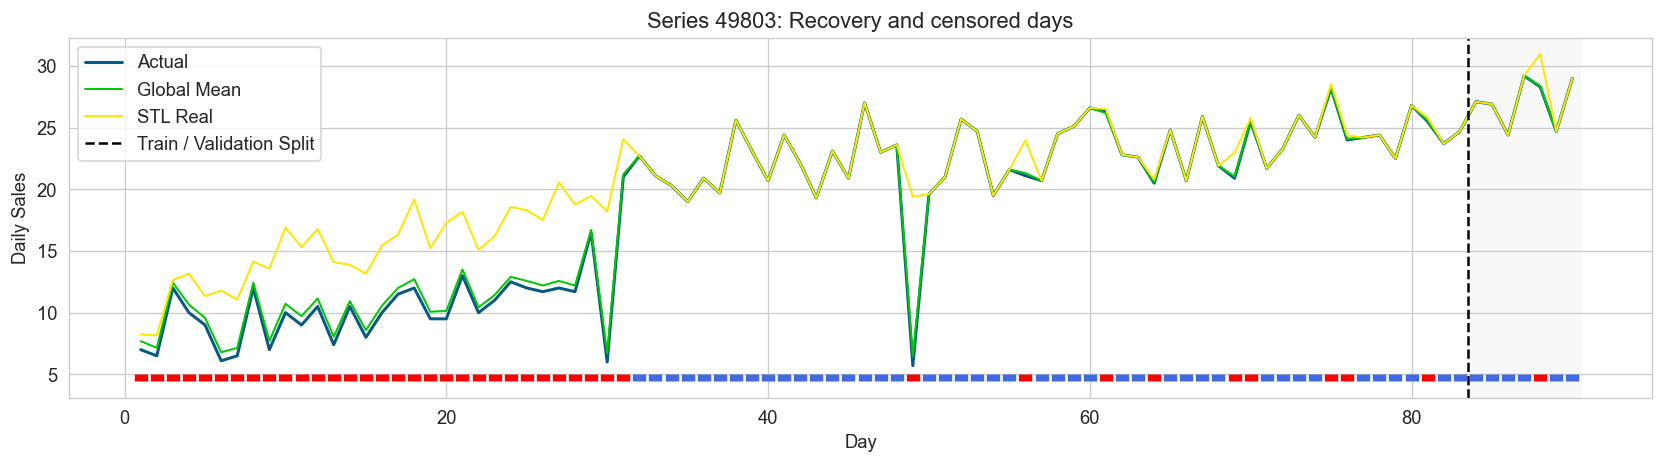

In [64]:
# --- Visualize: recovery overlay with censored days ---

example_sid3 = (train_r.groupby("series_id")["psd"].first().sort_values(ascending=False).index[5])

ex_train = train_r[train_r["series_id"] == example_sid3].copy()
ex_val = val_r[val_r["series_id"] == example_sid3].copy()

# Train + Validation zusammenführen
ex = pd.concat([ex_train, ex_val]).sort_values("day_idx")

fig, ax = plt.subplots(figsize=(14, 4))

# Actual sales
ax.plot(ex["day_idx"], ex["sale_amount"], color="#065A82", linewidth=1.8, label="Actual")

# Recoveries
ax.plot(ex["day_idx"], ex["recovered_daily_sales_global_mean"], color="#00C900", linewidth=1.2, label="Global Mean")

ax.plot(ex["day_idx"], ex["recovered_daily_sales_stl_real"], color="#FFE600", linewidth=1.2, label="STL Real")

# Train-/Validation-Grenze
split_day = ex_val["day_idx"].min()

ax.axvline(split_day - 0.5, color="black", linestyle="--", linewidth=1.5, label="Train / Validation Split")

# Validation-Bereich leicht einfärben
ax.axvspan(split_day - 0.5, ex["day_idx"].max() + 0.5, color="lightgray", alpha=0.15)

ymin, ymax = ax.get_ylim()
bar_y = ymin
bar_height = 0.02 * (ymax - ymin)

for _, row in ex.iterrows():
    color = "red" if row["is_censored"] else "royalblue"

    ax.vlines(row["day_idx"], bar_y, bar_y + bar_height, color=color, linewidth=8, clip_on=False, zorder=10)


ax.set_title(f"Series {example_sid3}: Recovery and censored days")
ax.set_xlabel("Day")
ax.set_ylabel("Daily Sales")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

In [ ]:
# TODO 4 besten Kombinationen Recovery + Forecast auswählen und in chosen_pred eintragen (1. wird weiter unten noch spezifischer analysiert)
# 1
# 2
# 3
# 4

chosen_pred = ["autoencoder+arima_like_fast_vectorized", "diffusion+double_exponential_smoothing", "dlinear+global_mean_forecast"]

# load predictions
for pred in chosen_pred:
    loaded_arr = np.load(predictions_folder + "/" + pred + ".npy")
    val_r[pred] = loaded_arr

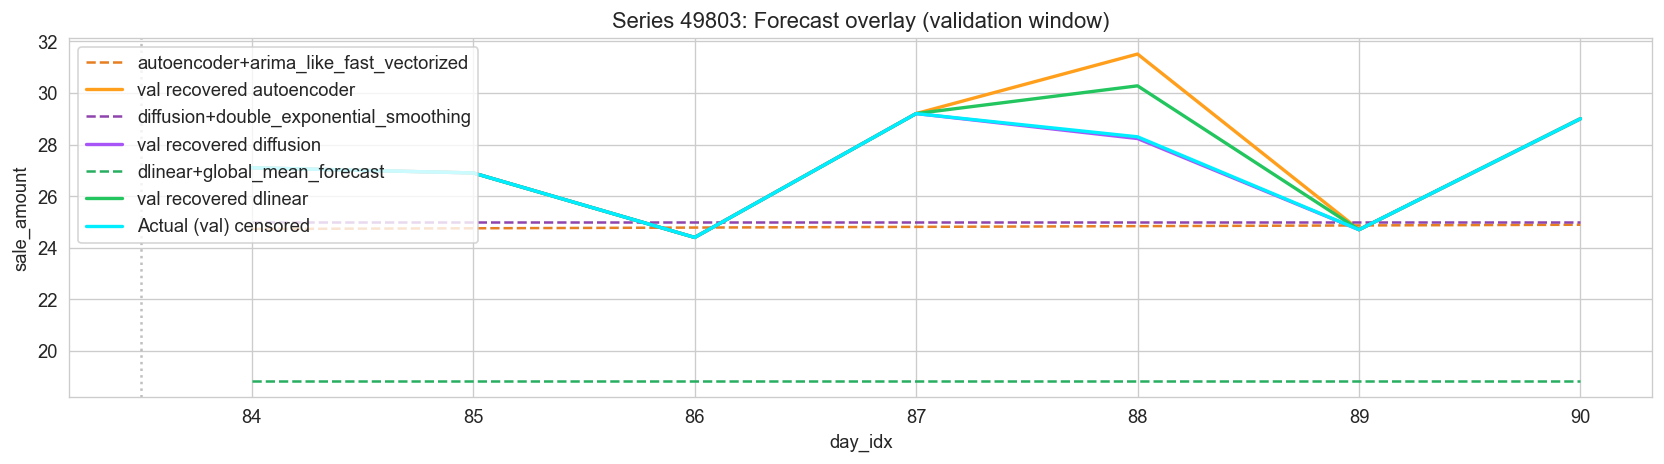

In [ ]:
colors = ["#E67E22", "#8E44AD", "#27AE60"]
colors_val_rec = ["#FF9F1C", "#A855F7", "#22C55E"]

# load predictions
for pred in chosen_pred:
    loaded_arr = np.load(predictions_folder + "/" + pred + ".npy")
    val_r[pred] = loaded_arr

# TODO maybe statt einer series_id ein merge aller???

### Recovery Analysis
# --- Visualize: forecast overlay for one series ---
example_sid3 = train_r.groupby("series_id")["psd"].first().sort_values(ascending=False).index[5]
ex = train_r[train_r["series_id"] == example_sid3].copy()
ex_val = val_r[val_r["series_id"] == example_sid3].copy()

fig, ax = plt.subplots(figsize=(14, 4))


for pred, color, color_val_rec in zip(chosen_pred, colors, colors_val_rec):
    ax.plot(ex_val["day_idx"], ex_val[pred], color=color, linewidth=1.5, linestyle="--", label=pred)
    ax.plot(ex_val["day_idx"], ex_val["recovered_daily_sales_" + pred.split("+")[0]], color=color_val_rec, linewidth=2, linestyle="-", label="val recovered " + pred.split("+")[0])


ax.plot(ex_val["day_idx"], ex_val["sale_amount"], color="#00EEFF", linewidth=2, linestyle="-", label="Actual (val) censored")

ax.axvline(ex_val["day_idx"].min() - 0.5, color="gray", linestyle=":", alpha=0.5)
ax.set_title(f"Series {example_sid3}: Forecast overlay (validation window)")
ax.set_xlabel("day_idx")
ax.set_ylabel("sale_amount")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

C:\Users\Nils\AppData\Local\Temp\ipykernel_24272\666028593.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x:


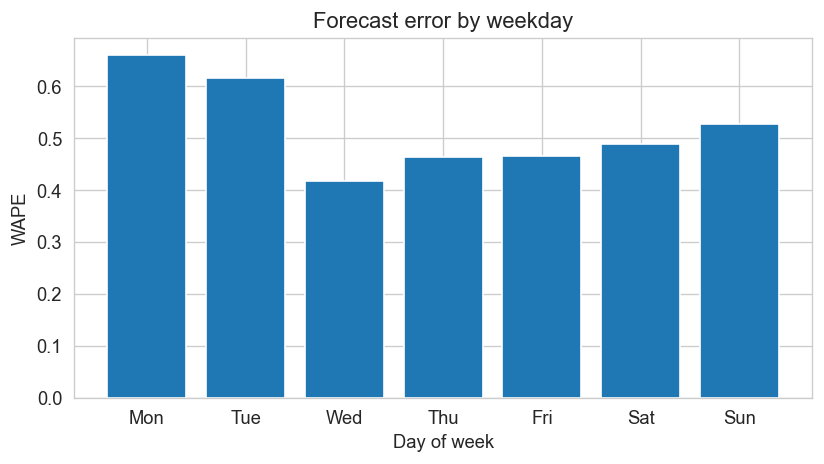

In [ ]:
# Analyse errors by day of week to detect weekly patterns
chosen_prediction = chosen_pred[0]

weekday_names = [
    "Mon", "Tue", "Wed", "Thu",
    "Fri", "Sat", "Sun"
]

val_r["weekday_name"] = val_r["datum"].dt.day_name().map({
    "Monday": "Mon",
    "Tuesday": "Tue",
    "Wednesday": "Wed",
    "Thursday": "Thu",
    "Friday": "Fri",
    "Saturday": "Sat",
    "Sunday": "Sun"
})

weekday_wape = (
    val_r
    .groupby("weekday_name")
    .apply(lambda x:
           np.abs(x[chosen_prediction] - x["sale_amount"]).sum()
           / x["sale_amount"].sum())
    .reindex(weekday_names)
)

plt.figure(figsize=(7,4))
plt.bar(weekday_wape.index, weekday_wape.values)
plt.ylabel("WAPE")
plt.xlabel("Day of week")
plt.title("Forecast error by weekday")
plt.tight_layout()
plt.show()

C:\Users\Nils\AppData\Local\Temp\ipykernel_24272\2923425875.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x:


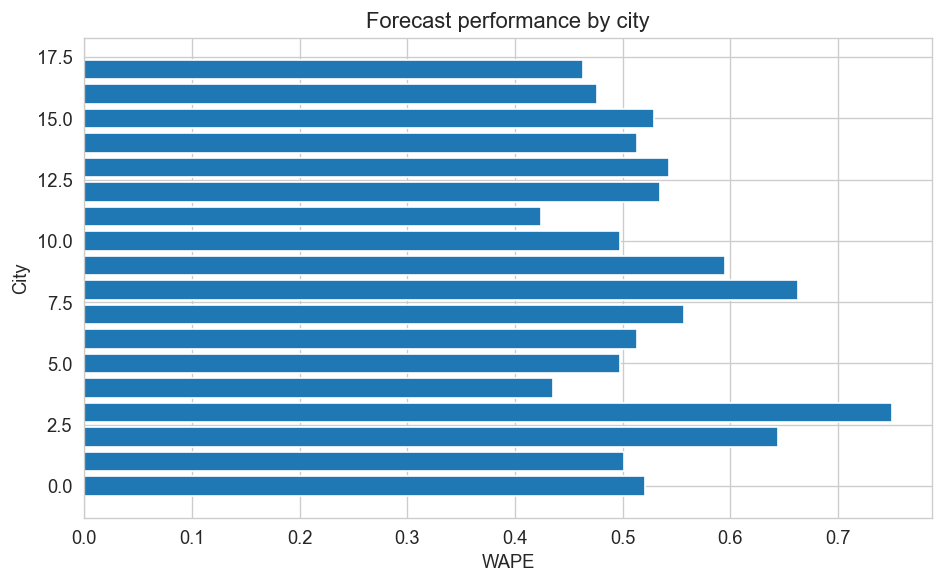

In [ ]:
#wape across cities:
city_wape = (
    val_r
    .groupby("city_id") # TODO city_id ? 
    .apply(lambda x:
           np.abs(x[chosen_prediction] - x["sale_amount"]).sum()
           / x["sale_amount"].sum())
    .sort_values()
)

plt.figure(figsize=(8,5))
plt.barh(city_wape.index, city_wape.values)
plt.xlabel("WAPE")
plt.ylabel("City")
plt.title("Forecast performance by city")
plt.tight_layout()
plt.show()

### 6d. Error Analysis

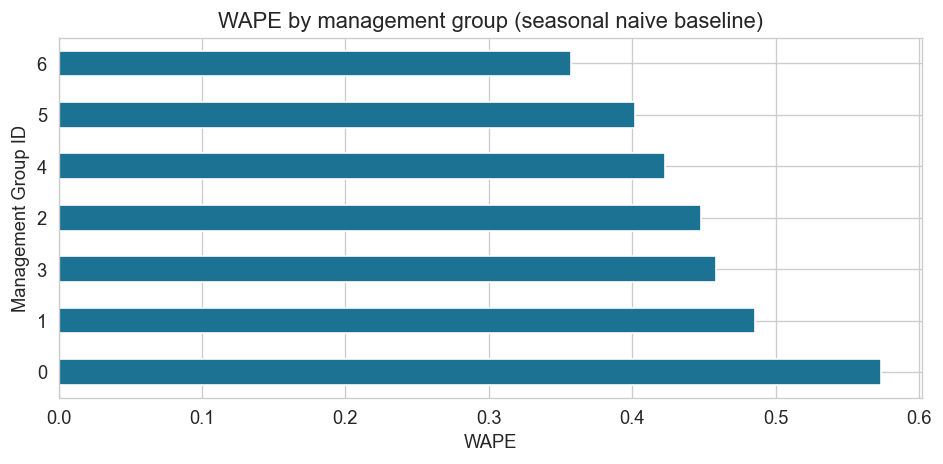

In [ ]:
# WAPE by management group
scored = val[val["stock_hour6_22_cnt"] == 0].copy()
scored["prediction"] = scored["pred_seasonal_naive"].clip(lower=0)
scored["abs_error"] = np.abs(scored["sale_amount"] - scored["prediction"])

group_wape = scored.groupby("management_group_id").apply(
    lambda g: utils.compute_wape(g["sale_amount"].values, g["prediction"].values),
    include_groups=False
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
group_wape.plot(kind="barh", color="#1C7293", edgecolor="white", ax=ax)
ax.set_title("WAPE by management group (seasonal naive baseline)")
ax.set_xlabel("WAPE")
ax.set_ylabel("Management Group ID")
plt.tight_layout()
plt.show()

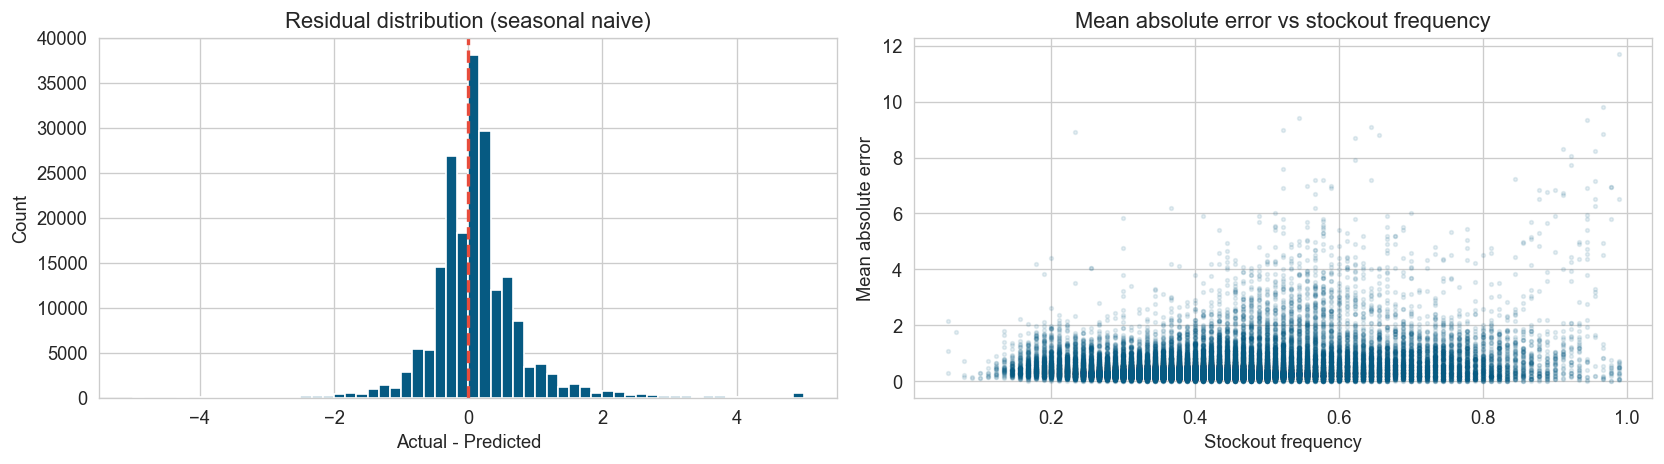

In [ ]:
# Residual distribution and error vs stockout frequency
scored["residual"] = scored["sale_amount"] - scored["prediction"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(scored["residual"].clip(-5, 5), bins=60, color="#065A82", edgecolor="white")
axes[0].axvline(0, color="#E74C3C", linestyle="--", linewidth=2)
axes[0].set_title("Residual distribution (seasonal naive)")
axes[0].set_xlabel("Actual - Predicted")
axes[0].set_ylabel("Count")

series_error = scored.groupby("series_id").agg(
    mean_abs_error=("abs_error", "mean"),
).reset_index()
series_error = series_error.merge(
    history.groupby("series_id")["is_censored"].mean().rename("stockout_freq"),
    on="series_id"
)
axes[1].scatter(series_error["stockout_freq"], series_error["mean_abs_error"], alpha=0.1, s=5, color="#065A82")
axes[1].set_title("Mean absolute error vs stockout frequency")
axes[1].set_xlabel("Stockout frequency")
axes[1].set_ylabel("Mean absolute error")

plt.tight_layout()
plt.show()

---
---
## 7. Next Steps

### Operations Track

**O1 \u2014 Diagnosis First**
- Extend the heatmaps to find which store x category combinations are most fragile
- Test whether promotions (`discount < 1`) increase late-day stockouts
- Run panel regressions with fixed effects to isolate drivers

**O2 \u2014 Decision First**
- Build a simple corrected demand estimate (impute censored hours from `hours_sale`)
- Compute newsvendor order quantities under raw vs. corrected demand
- Visualize the service vs. waste trade-off curve

### Data Science Track

**D1 \u2014 Direct Benchmark**
- Try exponential smoothing or a simple LightGBM with lag features
- Analyze errors by day-of-week to detect weekly patterns
- Compare WAPE across cities to find geographic patterns

**D2 \u2014 Recovery First**
- Try per-series mean imputation instead of global pool sampling
- Compare multiple recovery strategies on the same baseline
- Focus error analysis on high-stockout series where recovery matters most

### Cross-Track Synergies
- Operations insights (which products are most fragile) can inform DS feature engineering
- DS demand recovery estimates can feed back into operations policy evaluation
- Both tracks benefit from understanding the hourly censoring structure